# El mundo perdió 277.000 km² de árboles en un solo año. ¿A dónde se fueron?

En 2018 desapareció una superficie de árboles mayor que todo el Reino Unido. La pregunta incómoda no es *cuánto* — es *a dónde fue a parar*. Y la respuesta no es la que el titular "deforestación" te hace imaginar.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Global extent and drivers of tree cover loss quantified with high-resolution satellite data* — Tyukavina et al., **Science** (2026)
**DOI:** [10.1126/science.adz9042](https://doi.org/10.1126/science.adz9042)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-07-perdida-cobertura-arborea-global/notebook.ipynb)

> 🎬 Video: *[Pendiente]*

## ¿Cómo lo midieron?

Hasta ahora, los mapas globales de pérdida de bosque eran de baja resolución: registraban que *algo* desapareció, pero no qué pasó después. ¿Lo talaron y volvió a crecer? ¿Lo quemó un incendio? ¿O lo convirtieron en potrero para siempre?

Así lo resolvieron: tomaron **600 cuadros de 5×5 km** repartidos al azar por el mundo y los miraron con satélite de **alta resolución (3 a 10 metros)** — fino como para identificar, parche por parche, la causa de cada pérdida y en qué terminó la tierra. Eso es lo que permite separar lo temporal de lo permanente.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERDIDA_TOTAL_KM2 = 277324      # Pérdida total global de cobertura arbórea, 2018 (estimada)
N_BLOQUES = 600                 # Bloques de 5×5 km muestreados
FUENTE = 'Fuente: Tyukavina et al. (2026), Science | Datos: Zenodo (muestra de 600 bloques)'
COLOR_DATOS = '#2563EB'         # Azul CaM
COLOR_ALERTA = '#DC2626'        # Rojo — conversión permanente
COLOR_SECUND = '#059669'        # Emerald
COLOR_REF = '#D97706'           # Amber
COLOR_GRIS = '#BBBBBB'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los datos derivados (survey-weighted)
grupo = pd.read_csv('datos/perdida_por_grupo.csv')
natural = pd.read_csv('datos/perdida_natural_por_driver.csv')
region = pd.read_csv('datos/perdida_por_region.csv')
bloques = pd.read_csv('datos/distribucion_perdida_bloque.csv')

print(f'Pérdida total estimada 2018: {PERDIDA_TOTAL_KM2:,.0f} km²'.replace(',', '.'))
print(f'Bloques muestreados: {N_BLOQUES}  |  con pérdida > 0: {(bloques.pct_bloque_perdido > 0).sum()}')
print(f'Macro-categorías: {len(grupo)}  |  Regiones: {len(region)}')

Pérdida total estimada 2018: 277.324 km²
Bloques muestreados: 600  |  con pérdida > 0: 439
Macro-categorías: 5  |  Regiones: 7


No toda la pérdida es para siempre.

Aquí está.

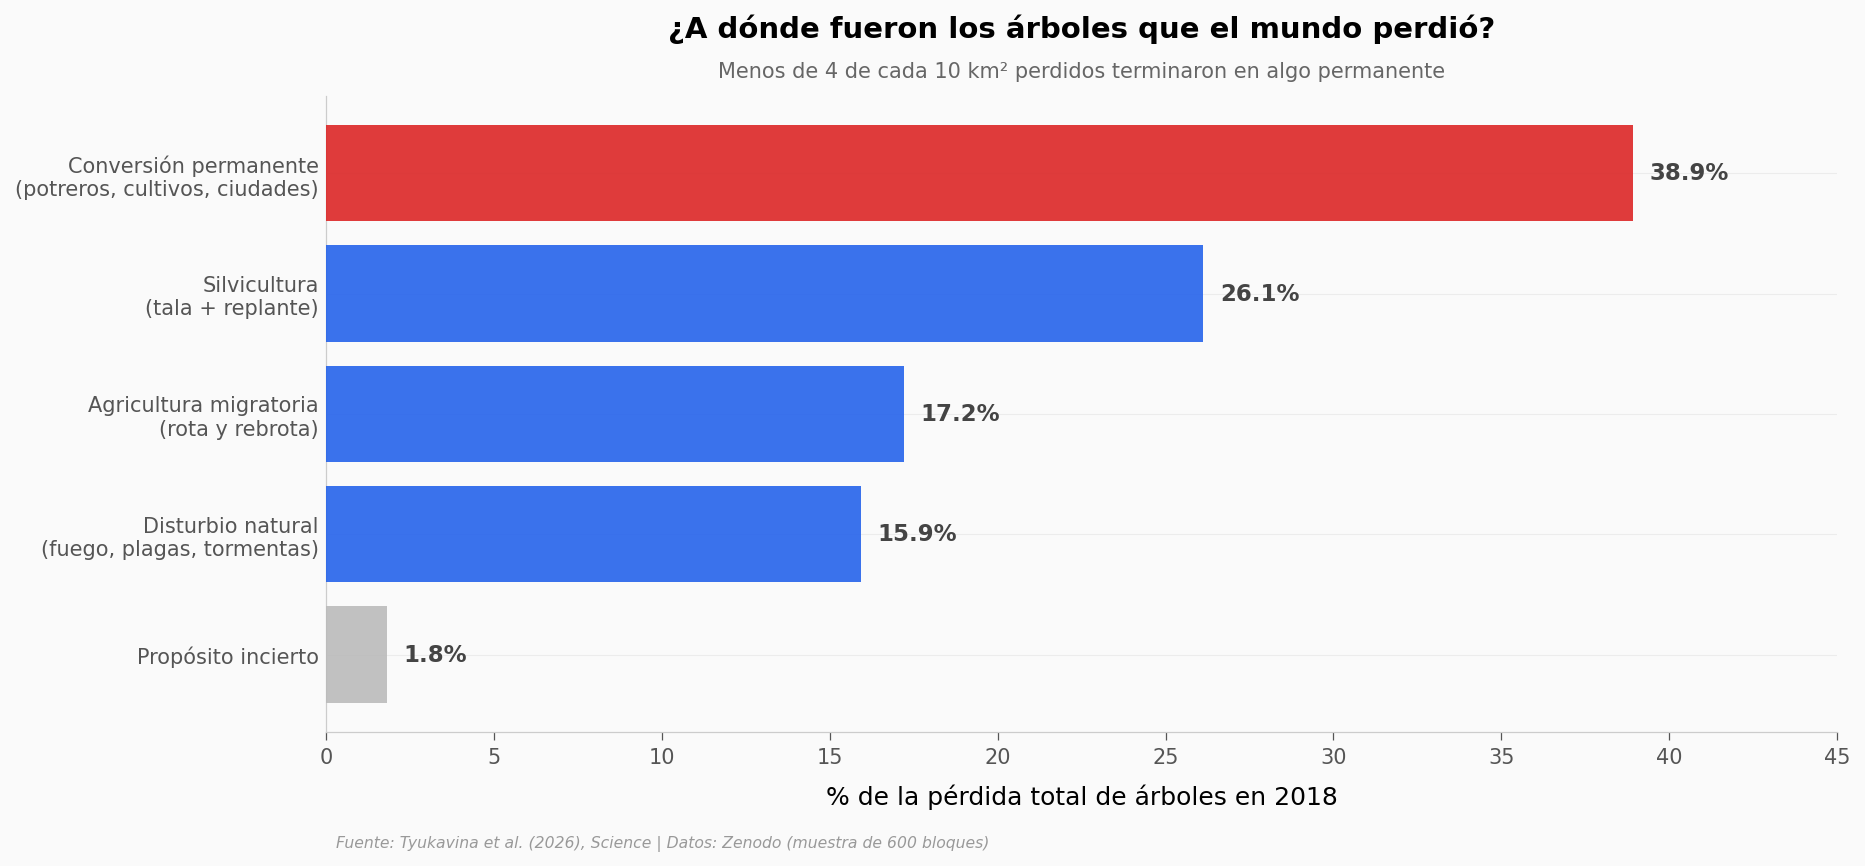

In [2]:
# Gráfica hero — ¿en qué terminó cada km² de árboles perdido?
labels_es = {
    'Conversion permanente': 'Conversión permanente\n(potreros, cultivos, ciudades)',
    'Silvicultura': 'Silvicultura\n(tala + replante)',
    'Agricultura migratoria': 'Agricultura migratoria\n(rota y rebrota)',
    'Disturbio natural': 'Disturbio natural\n(fuego, plagas, tormentas)',
    'Proposito incierto': 'Propósito incierto',
}
g = grupo.copy()
g['label'] = g['grupo'].map(labels_es)
g = g.sort_values('pct_perdida_total')   # menor abajo→mayor arriba en barh

# Solo la conversión permanente es pérdida que no vuelve → rojo. El resto, azul/gris.
colors = [COLOR_ALERTA if grp == 'Conversion permanente'
          else (COLOR_GRIS if grp == 'Proposito incierto' else COLOR_DATOS)
          for grp in g['grupo']]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.barh(g['label'], g['pct_perdida_total'], color=colors, alpha=0.9, zorder=3)
for bar, pct in zip(bars, g['pct_perdida_total']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold',
            color='#444444')

ax.set_xlabel('% de la pérdida total de árboles en 2018')
ax.set_xlim(0, 45)
ax.set_title('¿A dónde fueron los árboles que el mundo perdió?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Menos de 4 de cada 10 km² perdidos terminaron en algo permanente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perdida_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que cambia la historia: **solo el 38,9% de la pérdida fue conversión permanente** — tierra que dejó de ser bosque para volverse potrero, cultivo o ciudad. El resto rota o se recupera.

La silvicultura (26,1%) tala y vuelve a plantar. La agricultura migratoria (17,2%) abre un claro, lo cultiva unos años y lo deja descansar mientras el bosque rebrota. Los disturbios naturales (15,9%) — fuego, plagas, tormentas — tampoco son uso humano permanente.

El titular "deforestación" mete todo esto en la misma bolsa. Los datos lo separan.

Pero hay una parte que sí desaparece para no volver: cuando un **bosque natural** se convierte en otro uso de la tierra.

¿Quién se queda con esa tierra?

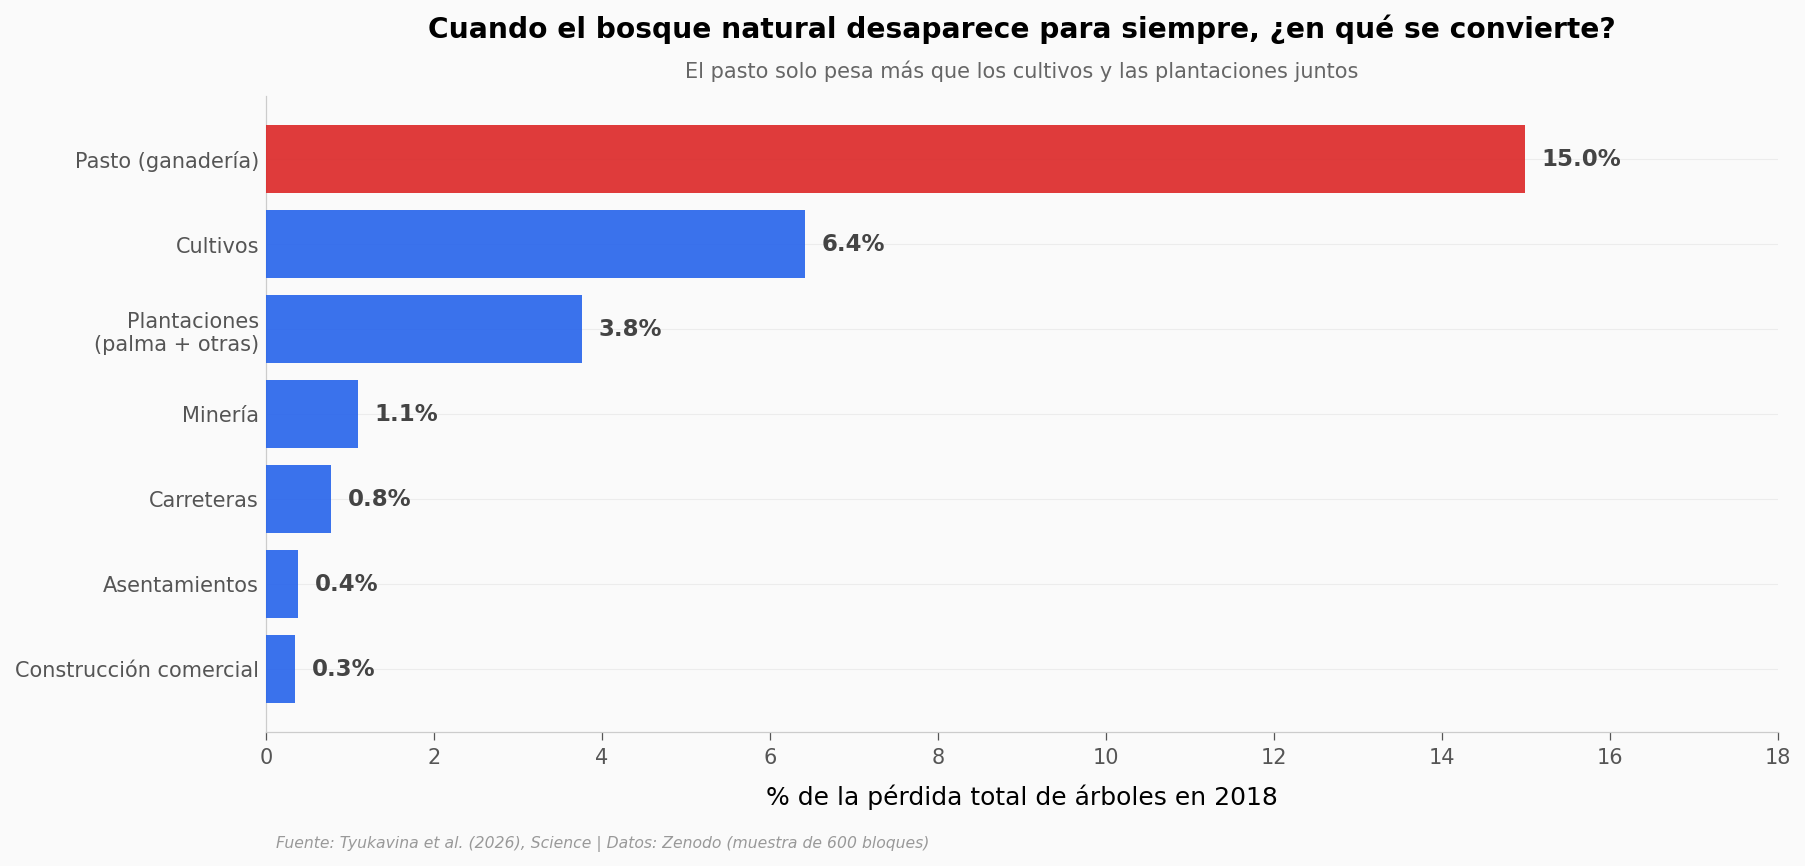

In [3]:
# Pérdida de cobertura NATURAL que terminó en conversión permanente, por causa.
# Filtramos solo los usos de la tierra que NO vuelven a ser bosque
# (excluye agricultura migratoria, silvicultura, fuego y disturbios: esos rotan o se recuperan).
conversion = {
    'Pasture': 'Pasto (ganadería)',
    'Cropland': 'Cultivos',
    'Mining': 'Minería',
    'Road': 'Carreteras',
    'Settlement': 'Asentamientos',
    'Commercial construction': 'Construcción comercial',
    'Energy infrastructure': 'Infraestructura energética',
    'Flood dams': 'Represas',
}
nat = natural.set_index('driver')

# Plantaciones: el abstract agrupa palma + no madereras como un solo bloque (3,8%)
plantaciones = nat.loc['Palm plantation', 'pct_perdida_total'] + \
               nat.loc['Non-timber tree plantation', 'pct_perdida_total']

filas = []
for en, es in conversion.items():
    if en in nat.index:
        filas.append((es, nat.loc[en, 'pct_perdida_total']))
filas.append(('Plantaciones\n(palma + otras)', plantaciones))
conv_full = pd.DataFrame(filas, columns=['causa', 'pct'])
total_conv = conv_full['pct'].sum()          # total real de conversión (incluye las marginales)
conv = conv_full[conv_full['pct'] >= 0.1].sort_values('pct')  # graficar solo causas visibles

# Pasto es la causa #1 de conversión permanente → rojo
colors = [COLOR_ALERTA if c == 'Pasto (ganadería)' else COLOR_DATOS for c in conv['causa']]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.barh(conv['causa'], conv['pct'], color=colors, alpha=0.9, zorder=3)
for bar, pct in zip(bars, conv['pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold', color='#444444')

ax.set_xlabel('% de la pérdida total de árboles en 2018')
ax.set_xlim(0, 18)
ax.set_title('Cuando el bosque natural desaparece para siempre, ¿en qué se convierte?',
             fontsize=13.5, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El pasto solo pesa más que los cultivos y las plantaciones juntos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/conversion_natural.png', dpi=200, bbox_inches='tight')
plt.show()

El pasto gana por amplio margen: la ganadería sola explica **15 de cada 100 km²** de árboles perdidos en todo el planeta — más que los cultivos y las plantaciones juntos.

¿Y dónde se concentra toda esta pérdida?

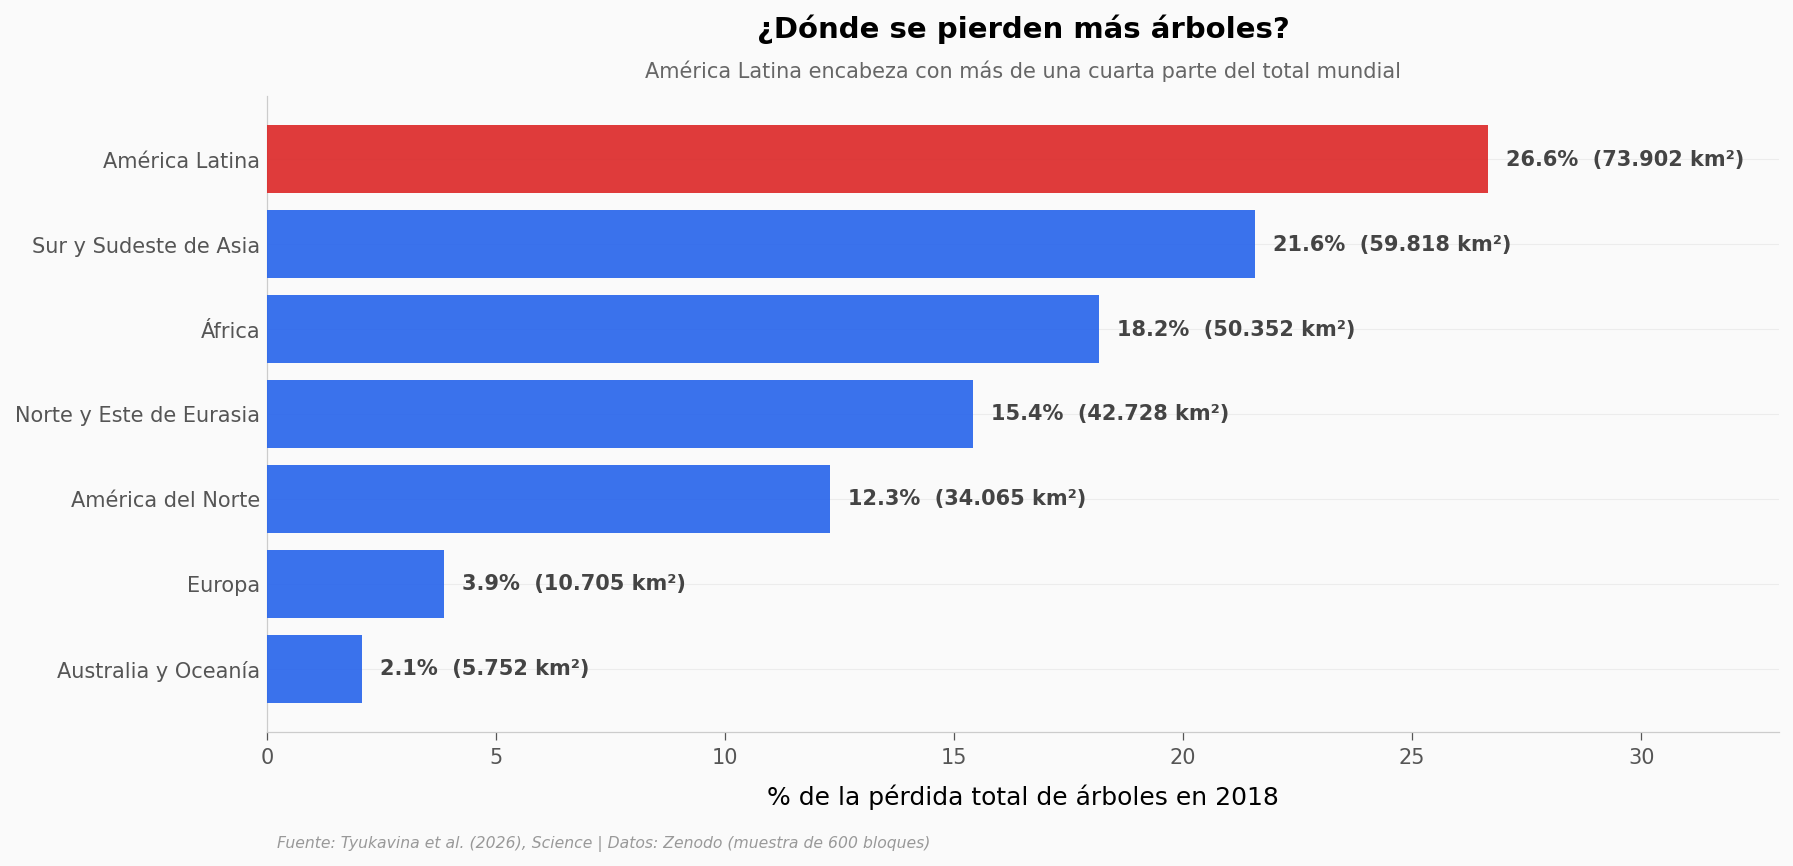

In [4]:
# Pérdida por región geográfica
r = region.sort_values('pct_perdida_total').copy()
# Nombres con tilde para el eje (el CSV los trae sin acentuar)
tildes = {'America Latina': 'América Latina', 'Africa': 'África',
          'America del Norte': 'América del Norte', 'Australia y Oceania': 'Australia y Oceanía'}
r['region_es'] = r['region'].replace(tildes)
# América Latina destaca como la región con mayor pérdida → rojo
colors = [COLOR_ALERTA if reg == 'America Latina' else COLOR_DATOS for reg in r['region']]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.barh(r['region_es'], r['pct_perdida_total'], color=colors, alpha=0.9, zorder=3)
for bar, pct, area in zip(bars, r['pct_perdida_total'], r['area_km2']):
    txt = f"{pct:.1f}%  ({area:,.0f} km²)".replace(',', '.')
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            txt, va='center', fontsize=10, fontweight='bold', color='#444444')

ax.set_xlabel('% de la pérdida total de árboles en 2018')
ax.set_xlim(0, 33)
ax.set_title('¿Dónde se pierden más árboles?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'América Latina encabeza con más de una cuarta parte del total mundial',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perdida_por_region.png', dpi=200, bbox_inches='tight')
plt.show()

Una última pregunta. Esos 600 bloques se eligieron al azar por todo el mundo. Si la pérdida estuviera repartida pareja, casi todos tendrían un poco.

¿Es así, o la pérdida se amontona en unos pocos lugares?

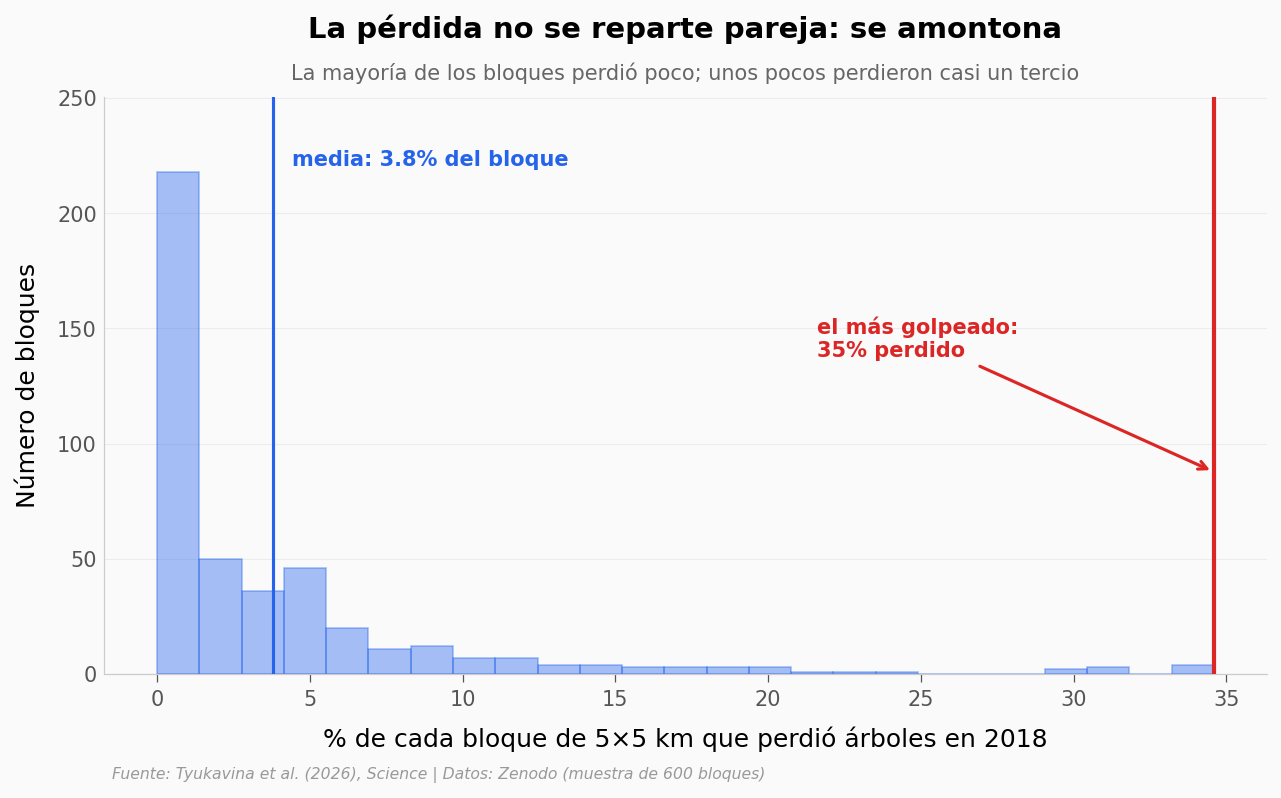

In [5]:
# Distribución: ¿cuánto perdió cada bloque? (solo los 439 con pérdida > 0)
con_perdida = bloques[bloques.pct_bloque_perdido > 0]['pct_bloque_perdido']
media = con_perdida.mean()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(con_perdida, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8, zorder=3)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(x=media, color=COLOR_DATOS, linewidth=1.5, zorder=4)
ax.text(media + 0.6, y_max * 0.88, f'media: {media:.1f}% del bloque',
        fontsize=10, fontweight='bold', color=COLOR_DATOS)
ax.axvline(x=con_perdida.max(), color=COLOR_ALERTA, linewidth=2.0, zorder=4)
ax.annotate(f'el más golpeado:\n{con_perdida.max():.0f}% perdido',
            xy=(con_perdida.max(), y_max * 0.35),
            xytext=(con_perdida.max() - 13, y_max * 0.55),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('% de cada bloque de 5×5 km que perdió árboles en 2018')
ax.set_ylabel('Número de bloques')
ax.set_title('La pérdida no se reparte pareja: se amontona',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La mayoría de los bloques perdió poco; unos pocos perdieron casi un tercio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_bloques.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El mundo perdió ~277.000 km² de árboles en 2018 | ✅ | Estimación de la muestra: 277.324 km² (paper: 277.000 km², dif. 0,1%). Es estimación de 600 bloques, no censo. |
| Menos del 40% fue conversión permanente | ✅ | Conversión permanente = 38,9% del total. El resto rota o se recupera (silvicultura, agricultura migratoria, disturbios). |
| El pasto es la causa #1 de conversión de bosque natural | ✅ | Pasto 15,0%, por encima de cultivos (6,4%) y plantaciones (3,8%). Reproduce los números nombrados en el abstract. |
| La conversión de bosque natural suma ~29% | ⚠️ | Nuestra reconstrucción de las causas de conversión da 27,8%; el paper reporta 29,0%. La brecha (~1,2 pp) es definicional: el paper incluye márgenes como "tala de propósito incierto". |
| América Latina lidera la pérdida regional | ✅ | 26,6% del total mundial (73.902 km²), seguida por Sur y Sudeste de Asia (21,6%). |
| La pérdida se concentra geográficamente | ✅ | De 600 bloques, 439 tuvieron pérdida; la mediana fue baja y unos pocos llegaron al 35% del bloque. Por eso el muestreo fue estratificado. |

> **Limitaciones:** (1) Es una **estimación** a partir de 600 bloques de 5×5 km, no un censo global — cada cifra tiene incertidumbre de muestreo. (2) Diseño **observacional**: describe proporciones y atribuye causas próximas, no prueba relaciones causales activas. (3) Corresponde a **un solo año** (2018); no es una tendencia temporal. (4) La frontera entre "conversión permanente" y "pérdida temporal" depende de definiciones del propio estudio.

## Ahora tú

Los datos están aquí. Tres preguntas para explorar:

1. **¿Cómo cambia el ranking si miras área absoluta en vez de porcentaje?** Pista: ordena `region` por `area_km2` en lugar de `pct_perdida_total`.
2. **¿Qué fracción de la pérdida es "recuperable" vs permanente?** Pista: suma en `grupo` todo menos `'Conversion permanente'` y `'Proposito incierto'`.
3. **¿Cuántos bloques concentran la mitad de toda la pérdida?** Pista: ordena `bloques.pct_bloque_perdido` de mayor a menor y mira la suma acumulada.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántos bloques concentran la mitad de toda la pérdida medida?
orden = bloques.sort_values('pct_bloque_perdido', ascending=False).reset_index(drop=True)
acum = orden['pct_bloque_perdido'].cumsum()
mitad = acum.iloc[-1] / 2
n_mitad = int((acum <= mitad).sum()) + 1
con_perdida = (bloques.pct_bloque_perdido > 0).sum()

print(f'Bloques con alguna pérdida: {con_perdida} de {len(bloques)}')
print(f'Bloques que concentran la mitad de la pérdida medida: {n_mitad}')
print(f'Es decir, el {100*n_mitad/con_perdida:.0f}% de los bloques afectados '
      f'acumula la mitad del daño.')

Bloques con alguna pérdida: 439 de 600
Bloques que concentran la mitad de la pérdida medida: 46
Es decir, el 10% de los bloques afectados acumula la mitad del daño.


## Créditos

- **Paper:** Tyukavina et al. (2026), *Global extent and drivers of tree cover loss quantified with high-resolution satellite data*, **Science**. DOI: [10.1126/science.adz9042](https://doi.org/10.1126/science.adz9042)
- **Datos:** muestra de 600 bloques, [Zenodo](https://doi.org/10.5281/zenodo.17652508) · [código archivado](https://doi.org/10.5281/zenodo.17652863)
- **Licencia datos:** ver repositorio Zenodo de origen
- **Repo del notebook:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

---
*Ciencia a Mordiscos — El Lab. Datos verificados, gráficas reproducibles.*

## Fuentes

**Paper**: [Global extent and drivers of tree cover loss quantified with high-resolution satellite data](https://doi.org/10.1126/science.adz9042)  
*Science, 2026-06-04*

**Dataset canónico**: [Global 5km sample blocks with 2018 tree cover loss and its drivers mapped using PlanetScope and Sentinel-2 data](https://doi.org/10.5281/zenodo.17652508)  
*Zenodo — muestra de 600 bloques de 5×5 km*

**Referencias citadas**: [código archivado del estudio](https://doi.org/10.5281/zenodo.17652863) (Zenodo)

*15 afirmaciones del notebook verificadas contra estas fuentes*